# 🌾 AgriSmart AI — Crop Recommendation Machine Learning Pipeline

This notebook provides the complete data science and machine learning workflow for recommending optimal crops based on soil nutrients and meteorological parameters.

### 📋 Contents:
1. **Library Imports & Data Ingestion**: Load dataset containing NPK and climatic variables.
2. **Exploratory Data Analysis (EDA)**: Inspect summary stats, distributions, and data hygiene.
3. **Data Preprocessing & Encoding**: Target variable transformation using `LabelEncoder`.
4. **Train-Test Stratified Split**: 80/20 data partition.
5. **Model Benchmarking**: Compare Decision Tree, Random Forest, and K-Nearest Neighbors (KNN).
6. **Model Evaluation**: Confusion Matrix, Classification Report, and Feature Importance.
7. **Top-3 Inference Engine**: Custom ranking function returning probability distributions.
8. **Artifact Serialization**: Export trained model and encoder to `models/` for the FastAPI backend.

In [1]:
# =============================================================================
# 1. IMPORT LIBRARIES AND LOAD DATASET
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Load agricultural dataset (7 features + 1 target crop column)
data_path = '../data/Crop_Recommendation.csv'
df = pd.read_csv(data_path)

# Display first 5 samples
df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


## 🔍 2. Exploratory Data Analysis (EDA)

In [2]:
# Check dataset dimensions: (total rows, total columns)
print(f"Total records: {df.shape[0]} rows | Total attributes: {df.shape[1]} columns")
df.shape

Total records: 2200 rows | Total attributes: 8 columns


(2200, 8)

In [3]:
# Inspect feature column names
print("Feature Columns:", list(df.columns))
df.columns

Feature Columns: ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall', 'Crop']


Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall', 'Crop'],
      dtype='object')

In [4]:
# Dataset schema summary: Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
# Data Hygiene Check: Verify absence of missing (NaN/Null) values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64


In [6]:
# Check for duplicated rows
duplicates = df.duplicated().sum()
print(f"Duplicate records found: {duplicates}")

Duplicate records found: 0


In [7]:
# Class Balance Check: Number of samples per target crop
print(f"Total unique crop classes: {df['Crop'].nunique()}")
df['Crop'].value_counts()

Total unique crop classes: 22


Crop
Rice           100
Maize          100
Jute           100
Cotton         100
Coconut        100
Papaya         100
Orange         100
Apple          100
Muskmelon      100
Watermelon     100
Grapes         100
Mango          100
Banana         100
Pomegranate    100
Lentil         100
Blackgram      100
MungBean       100
MothBeans      100
PigeonPeas     100
KidneyBeans    100
ChickPea       100
Coffee         100
Name: count, dtype: int64

## ⚙️ 3. Feature Selection & Label Encoding

In [8]:
# Separate independent input features (X) and dependent target variable (y)
X = df.drop('Crop', axis=1)  # Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH, Rainfall
y = df['Crop']               # Target crop category

print(f"Features shape (X): {X.shape}")
print(f"Target shape   (y): {y.shape}")

Features shape (X): (2200, 7)
Target shape   (y): (2200,)


In [9]:
# Convert categorical string crop names into numerical indices (0 to 21)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Verify first 10 encoding mappings
print("Sample original labels :", y.iloc[:10].values)
print("Sample encoded indices :", y_encoded[:10])

Sample original labels : ['Rice' 'Rice' 'Rice' 'Rice' 'Rice' 'Rice' 'Rice' 'Rice' 'Rice' 'Rice']
Sample encoded indices : [20 20 20 20 20 20 20 20 20 20]


In [10]:
# Display full dictionary of all 22 crop class index mappings
print("=== Crop Class Mapping (Index -> Name) ===")
for idx, crop_name in enumerate(label_encoder.classes_):
    print(f"Index {idx:2d} -> {crop_name}")

=== Crop Class Mapping (Index -> Name) ===
Index  0 -> Apple
Index  1 -> Banana
Index  2 -> Blackgram
Index  3 -> ChickPea
Index  4 -> Coconut
Index  5 -> Coffee
Index  6 -> Cotton
Index  7 -> Grapes
Index  8 -> Jute
Index  9 -> KidneyBeans
Index 10 -> Lentil
Index 11 -> Maize
Index 12 -> Mango
Index 13 -> MothBeans
Index 14 -> MungBean
Index 15 -> Muskmelon
Index 16 -> Orange
Index 17 -> Papaya
Index 18 -> PigeonPeas
Index 19 -> Pomegranate
Index 20 -> Rice
Index 21 -> Watermelon


## ✂️ 4. Stratified Train-Test Split (80/20)

In [11]:
# Split data into 80% training set and 20% validation test set
# stratify=y_encoded ensures proportional distribution of each crop in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set samples : {len(X_train)} (80%)")
print(f"Testing set samples  : {len(X_test)} (20%)")
print(f"Total input features : {X_train.shape[1]}")

Training set samples : 1760 (80%)
Testing set samples  : 440 (20%)
Total input features : 7


## 🌲 5. Model Training & Comparison

In [12]:
# -----------------------------------------------------
# Model 1: Decision Tree Classifier (Baseline)
# -----------------------------------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Test Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree Test Accuracy: 97.95%


In [13]:
# -----------------------------------------------------
# Model 2: Random Forest Classifier (Ensemble)
# -----------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Test Accuracy: 99.55%


In [14]:
# -----------------------------------------------------
# Model 3: K-Nearest Neighbors (KNN with Feature Scaling)
# -----------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Test Accuracy: {knn_accuracy * 100:.2f}%")

KNN Test Accuracy: 97.95%


In [15]:
# -----------------------------------------------------
# Model Comparison Summary Table
# -----------------------------------------------------
model_results = pd.DataFrame({
    "Model": ["Random Forest", "Decision Tree", "KNN"],
    "Accuracy (%)": [
        round(rf_accuracy * 100, 2),
        round(dt_accuracy * 100, 2),
        round(knn_accuracy * 100, 2)
    ]
}).sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

print("=== Model Benchmarking Leaderboard ===")
print(model_results)
print(f"\n🏆 Best Performing Model: {model_results.iloc[0]['Model']} ({model_results.iloc[0]['Accuracy (%)']}%)")

=== Model Benchmarking Leaderboard ===
           Model  Accuracy (%)
0  Random Forest         99.55
1  Decision Tree         97.95
2            KNN         97.95

🏆 Best Performing Model: Random Forest (99.55%)


## 📊 6. Comprehensive Random Forest Evaluation

In [16]:
# Classification Report: Precision, Recall, F1-Score per crop class
print("=== Random Forest Detailed Classification Report ===")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

=== Random Forest Detailed Classification Report ===
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
   Blackgram       1.00      0.95      0.97        20
    ChickPea       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       1.00      1.00      1.00        20
      Grapes       1.00      1.00      1.00        20
        Jute       0.95      1.00      0.98        20
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       1.00      1.00      1.00        20
       Maize       0.95      1.00      0.98        20
       Mango       1.00      1.00      1.00        20
   MothBeans       1.00      1.00      1.00        20
    MungBean       1.00      1.00      1.00        20
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00     

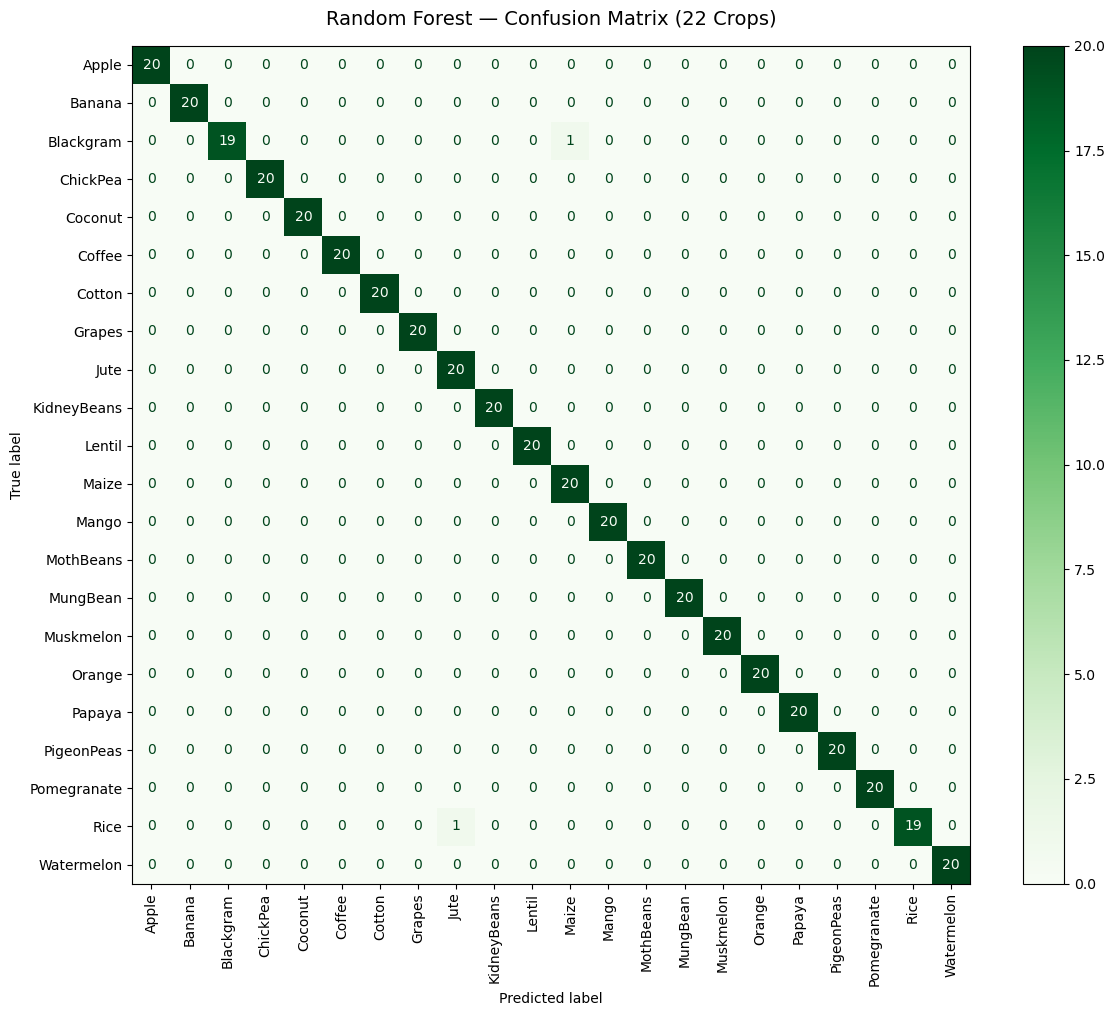

In [17]:
# Confusion Matrix: Plot multi-class prediction accuracy heatmap
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap="Greens", xticks_rotation=90, colorbar=True)
plt.title("Random Forest — Confusion Matrix (22 Crops)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

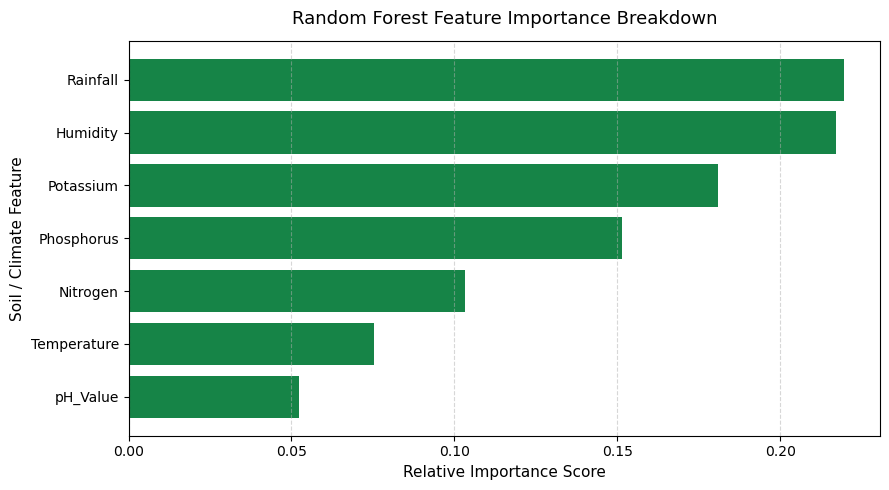

In [18]:
# Feature Importance Analysis: Calculate Gini importance scores
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="#168447"
)
plt.xlabel("Relative Importance Score", fontsize=11)
plt.ylabel("Soil / Climate Feature", fontsize=11)
plt.title("Random Forest Feature Importance Breakdown", fontsize=13, pad=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 🔮 7. Top-3 Crop Recommendation Engine

In [19]:
def recommend_crops(
    nitrogen: float,
    phosphorus: float,
    potassium: float,
    temperature: float,
    humidity: float,
    ph_value: float,
    rainfall: float,
    top_n: int = 3
):
    """
    Inference function that outputs ranked crop recommendations with model confidence.
    """
    input_data = pd.DataFrame([{
        "Nitrogen": nitrogen,
        "Phosphorus": phosphorus,
        "Potassium": potassium,
        "Temperature": temperature,
        "Humidity": humidity,
        "pH_Value": ph_value,
        "Rainfall": rainfall,
    }])
    
    # Predict probability distribution across all classes
    probs = rf_model.predict_proba(input_data)[0]
    top_indices = np.argsort(probs)[::-1][:top_n]
    
    recommendations = []
    for idx in top_indices:
        crop_name = label_encoder.inverse_transform([idx])[0]
        confidence = round(float(probs[idx] * 100), 2)
        recommendations.append((crop_name, confidence))
        
    return recommendations

# Test inference with sample agricultural input
sample_output = recommend_crops(
    nitrogen=80, phosphorus=40, potassium=50,
    temperature=28.0, humidity=62.0, ph_value=6.8, rainfall=600.0
)

print("=== Top 3 Predicted Crops ===")
for rank, (crop, conf) in enumerate(sample_output, start=1):
    print(f"#{rank} {crop:<15} (Confidence: {conf}%)")

=== Top 3 Predicted Crops ===
#1 Coffee          (Confidence: 49.5%)
#2 Jute            (Confidence: 15.0%)
#3 Rice            (Confidence: 13.0%)


## 💾 8. Model Serialization & Export for FastAPI Backend

In [20]:
# Create destination directory for production artifacts
os.makedirs("../models", exist_ok=True)

# Save trained Random Forest classifier
model_file = "../models/crop_recommendation_model.joblib"
joblib.dump(rf_model, model_file)
print(f"✅ Model saved: {model_file} ({os.path.getsize(model_file) / (1024*1024):.2f} MB)")

# Save trained Label Encoder
encoder_file = "../models/crop_label_encoder.joblib"
joblib.dump(label_encoder, encoder_file)
print(f"✅ Label encoder saved: {encoder_file}")

✅ Model saved: ../models/crop_recommendation_model.joblib (6.94 MB)
✅ Label encoder saved: ../models/crop_label_encoder.joblib


In [21]:
# Sanity Test: Reload artifacts and perform a test prediction
loaded_model = joblib.load("../models/crop_recommendation_model.joblib")
loaded_encoder = joblib.load("../models/crop_label_encoder.joblib")

test_df = pd.DataFrame([{
    "Nitrogen": 80,
    "Phosphorus": 40,
    "Potassium": 50,
    "Temperature": 28,
    "Humidity": 62,
    "pH_Value": 6.8,
    "Rainfall": 600,
}])

pred_idx = loaded_model.predict(test_df)[0]
pred_crop = loaded_encoder.inverse_transform([pred_idx])[0]
print(f"✅ Artifact verification passed! Test prediction: {pred_crop}")

✅ Artifact verification passed! Test prediction: Coffee
